In [1]:
# --- Import Libraries ---
# pandas     : Data manipulation and analysis
# matplotlib : Data visualization and plotting
# seaborn    : Statistical data visualization
# numpy      : Numerical computations and array operations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# LOAD DATASET
# - read_csv  : Reads CSV file into Pandas DataFrame
# - filepath  : Local path to heart.csv file
dataset = pd.read_csv(r'C:\Users\ahmad\Desktop\ML  Dataset\heart.csv')

In [3]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Check total rows and columns in dataset
dataset.shape

(303, 14)

In [5]:
# Rename the columns names
# - rename()  : Renames column names for better readability
# - columns   : Dictionary of old name → new name mapping
# - inplace   : Apply changes directly to dataset
# - Purpose   : Make column names more understandable
dataset.rename(columns={
    "age" : "Age",  # Patient age in years
    "sex" : "Gender", # Patient gender (0=Female, 1=Male)
    "cp" : "Chestpain", # Chest pain type (0-3)
    "trestbps" : "RestingBP", # Resting blood pressure
    "chol" : "Cholesterol", # Serum cholesterol in mg/dl
    "fbs" : "FastingBS", # Fasting blood sugar > 120 mg/dl
    "restecg" : "RestingECG", # Resting ECG results
    "thalach" : "MaxHR", # Maximum heart rate achieved
    "exang" :  "ExcercsieAngina", # Exercise induced angina
    "oldpeak" : "ST_Depression", # ST depression induced by exercise
    "slope" : "ST_Slope", # Slope of peak exercise ST segment
    "ca" : "MajorVessels", # Number of major vessels (0-3)
    "thal" : "Thalassemia",  # Thalassemia type
    "target" : "HeartDisease" # Target (0=No Disease, 1=Disease)
},inplace=True) # Apply changes directly to dataset

print("Update Dataset \n",dataset.head(5)) # Print first 5 rows after renaming columns
print("Columns Names \n",dataset.columns) # Print all updated column names

Update Dataset 
    Age  Gender  Chestpain  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   63       1          3        145          233          1           0   
1   37       1          2        130          250          0           1   
2   41       0          1        130          204          0           0   
3   56       1          1        120          236          0           1   
4   57       0          0        120          354          0           1   

   MaxHR  ExcercsieAngina  ST_Depression  ST_Slope  MajorVessels  Thalassemia  \
0    150                0            2.3         0             0            1   
1    187                0            3.5         0             0            2   
2    172                0            1.4         2             0            2   
3    178                0            0.8         2             0            2   
4    163                1            0.6         2             0            2   

   HeartDisease  
0             1  
1  

In [6]:
# Check structure, data types and non-null counts
# Shows int64, float64 data types per column
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              303 non-null    int64  
 1   Gender           303 non-null    int64  
 2   Chestpain        303 non-null    int64  
 3   RestingBP        303 non-null    int64  
 4   Cholesterol      303 non-null    int64  
 5   FastingBS        303 non-null    int64  
 6   RestingECG       303 non-null    int64  
 7   MaxHR            303 non-null    int64  
 8   ExcercsieAngina  303 non-null    int64  
 9   ST_Depression    303 non-null    float64
 10  ST_Slope         303 non-null    int64  
 11  MajorVessels     303 non-null    int64  
 12  Thalassemia      303 non-null    int64  
 13  HeartDisease     303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# Check missing values in each column
# Returns 0 → No missing values found
dataset.isnull().sum()

Age                0
Gender             0
Chestpain          0
RestingBP          0
Cholesterol        0
FastingBS          0
RestingECG         0
MaxHR              0
ExcercsieAngina    0
ST_Depression      0
ST_Slope           0
MajorVessels       0
Thalassemia        0
HeartDisease       0
dtype: int64

In [8]:
# Count total duplicate rows in dataset
# Returns number of duplicate rows found
duplicated = dataset.duplicated().sum()
print(duplicated)

1


In [9]:
# Show duplicate rows (keep first occurrence)
# Returns all rows that appear more than once
duplicated_row = dataset[dataset.duplicated()]
duplicated_row

,Age,Gender,Chestpain,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExcercsieAngina,ST_Depression,ST_Slope,MajorVessels,Thalassemia,HeartDisease
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [10]:
# Show ALL duplicate rows including first occurrence
# keep=False → marks all duplicate rows as True
duplicated_row = dataset[dataset.duplicated(keep=False)]
duplicated_row

,Age,Gender,Chestpain,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExcercsieAngina,ST_Depression,ST_Slope,MajorVessels,Thalassemia,HeartDisease
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [11]:
# - drop_duplicates() : Removes all duplicate rows
# - shape             : Verify rows reduced after removal
# Remove all duplicate rows from dataset
# Keeps first occurrence of each duplicate row
dataset = dataset.drop_duplicates()
# Verify shape after removing duplicates
# Row count should be reduced by number of duplicates
print("After Removing the Dupllicated Rows: \n",dataset.shape)

After Removing the Dupllicated Rows: 
 (302, 14)


In [12]:
# Check statistical summary of all numeric columns
# Shows count, mean, std, min, max for each column
dataset.describe()

,Age,Gender,Chestpain,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExcercsieAngina,ST_Depression,ST_Slope,MajorVessels,Thalassemia,HeartDisease
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [13]:
# Check all available column names in dataset
dataset.columns

Index(['Age', 'Gender', 'Chestpain', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExcercsieAngina', 'ST_Depression', 'ST_Slope',
       'MajorVessels', 'Thalassemia', 'HeartDisease'],
      dtype='str')

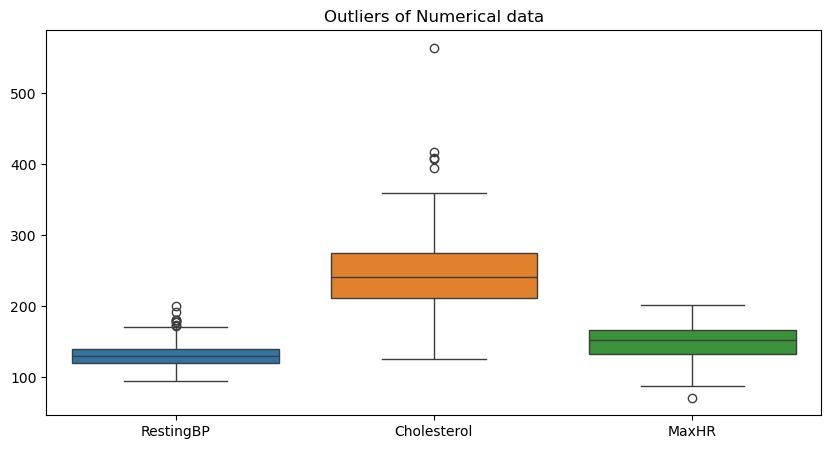

In [14]:
# CHECK OUTLIERS USING BOX PLOT
# - boxplot   : Visualizes outliers in numerical columns
# - Columns   : RestingBP, Cholesterol, MaxHR checked
# - Dots outside whiskers = Outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=dataset[["RestingBP","Cholesterol","MaxHR"]])
plt.title("Outliers of Numerical data")
plt.show()

In [15]:
#  HANDLE OUTLIERS USING IQR METHOD
# - Q1        : 25th percentile of data
# - Q3        : 75th percentile of data
# - IQR       : Interquartile Range = Q3 - Q1
# - max_val   : Lower fence = Q1 - (1.5 * IQR)
# - min_val   : Upper fence = Q3 + (1.5 * IQR)
# - np.where  : Replace outliers with fence values
# - Purpose   : Cap outliers instead of removing them
def handle_outlier(dataset,column):
    Q1 = dataset[column].quantile(0.25)
    Q3 = dataset[column].quantile(0.75)
    IQR = Q3 - Q1
    max_val = Q1 - (1.5 * IQR)
    min_val = Q3 + (1.5 * IQR)
    # Replace outliers with fence values
    # Values above upper fence → replaced with upper fence
    # Values below lower fence → replaced with lower fence
    dataset[column] = np.where(dataset[column] > max_val,max_val,
                               np.where(dataset[column] < min_val,min_val,dataset[column]))

# Apply outlier handling to numerical columns
handle_outlier(dataset,"RestingBP")
handle_outlier(dataset,"Cholesterol")
handle_outlier(dataset,"MaxHR")

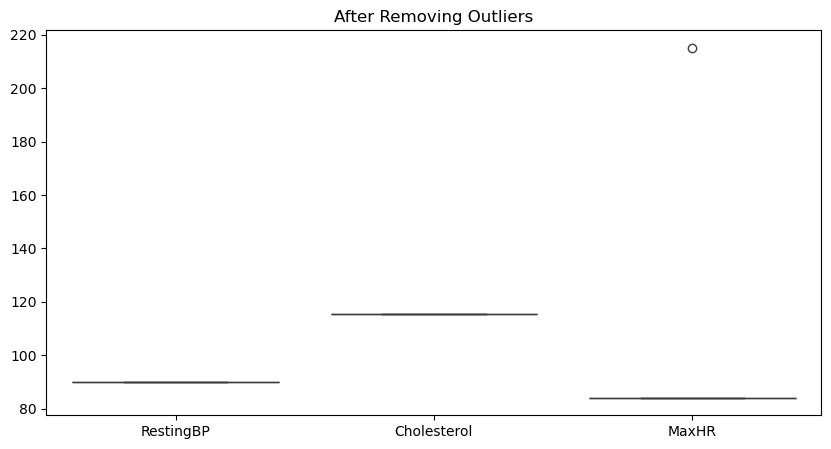

In [16]:
# Plot box plot after handling outliers
# Compare with previous box plot to verify improvement
plt.figure(figsize=(10,5))
sns.boxplot(data=dataset[["RestingBP","Cholesterol","MaxHR"]])
plt.title("After Removing Outliers")
plt.show()

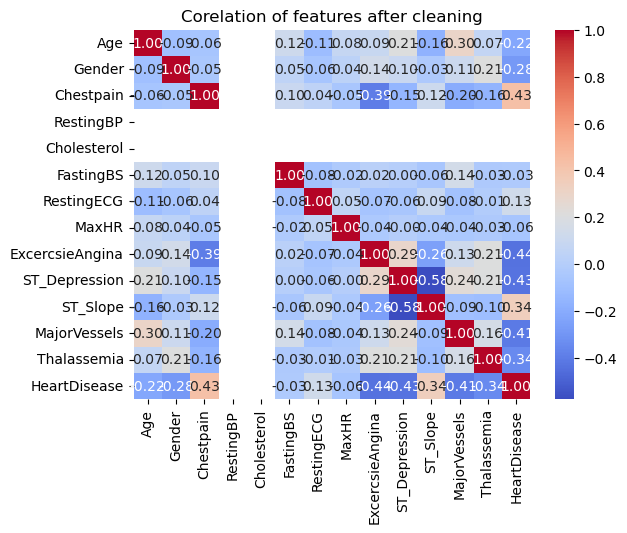

In [17]:
# CORRELATION HEATMAP
# - corr()    : Calculates correlation between all columns
# - heatmap   : Visualizes correlation as colored grid
# - annot     : Shows correlation values on each cell
# - fmt=".2f" : Shows values with 2 decimal places
# - cmap      : Color scheme (coolwarm = blue to red)
# - Purpose   : Identify strongly correlated features
# Plot correlation heatmap of all features
# Shows how strongly each feature relates to others
# Values close to 1 or -1 = Strong correlation
# Values close to 0 = Weak correlation
plt.Figure(figsize=(15,15))
sns.heatmap(dataset.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Corelation of features after cleaning")
plt.show()

In [18]:
# SEPARATE FEATURES AND TARGET
# - x         : Independent variables (input features)
# - y         : Dependent variable (target/output)
# - iloc[:,:-1]: Select all columns except last column
# - HeartDisease: Target column (0=No Disease, 1=Disease)
# X → All columns except last (HeartDisease)
# Contains all input features for model
x = dataset.iloc[:,:-1]
print("Input Features \n",x.shape)
# Y → Only HeartDisease column
# This is what model will learn to predict
y = dataset["HeartDisease"]

Input Features 
 (302, 13)


In [19]:
# DEFINE CATEGORICAL AND NUMERICAL COLUMNS
# - Categorical : Text/category based columns
#                 Need encoding before model training
# - Numerical   : Number based columns
#                 Need scaling before model training
categorical_columns = ["Gender","Chestpain","FastingBS","RestingECG","ExcercsieAngina","ST_Slope","MajorVessels","Thalassemia"]
numerical_columns = ["Age","RestingBP","Cholesterol","MaxHR","ST_Depression"]
print("Categorical Columns: \n",categorical_columns)
print("Numerical Columns: \n",numerical_columns)

Categorical Columns: 
 ['Gender', 'Chestpain', 'FastingBS', 'RestingECG', 'ExcercsieAngina', 'ST_Slope', 'MajorVessels', 'Thalassemia']
Numerical Columns: 
 ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'ST_Depression']


In [20]:
from sklearn.preprocessing import OneHotEncoder
# ENCODE CATEGORICAL COLUMNS
# - get_dummies   : Converts categories to binary columns
# - drop_first    : Drops first category to avoid redundancy
#                   Prevents multicollinearity in model
# - Purpose       : ML models need numeric input only
# Apply One Hot Encoding to all categorical columns
# Converts each category value into separate binary column
#Encoding the data
encoded_data = pd.get_dummies(dataset,columns=categorical_columns,drop_first=True)
print("After Encoded the Data: ",encoded_data.shape)
# Verify shape after encoding
# Column count increases due to new binary columns
encoded_data.head(3)

After Encoded the Data:  (302, 23)


,Age,RestingBP,Cholesterol,MaxHR,ST_Depression,HeartDisease,Gender_1,Chestpain_1,Chestpain_2,Chestpain_3,...,ExcercsieAngina_1,ST_Slope_1,ST_Slope_2,MajorVessels_1,MajorVessels_2,MajorVessels_3,MajorVessels_4,Thalassemia_1,Thalassemia_2,Thalassemia_3
0,63,90.0,115.375,84.125,2.3,1,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,37,90.0,115.375,84.125,3.5,1,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,41,90.0,115.375,84.125,1.4,1,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False


In [21]:
# FEATURE SCALING
# - StandardScaler  : Scales features to mean=0, std=1
# - fit_transform   : Learns mean/std then transforms data
# - Purpose         : Brings all numeric values to same scale
#                     Prevents larger values dominating model
from sklearn.preprocessing import StandardScaler
# Create StandardScaler object
scaler = StandardScaler()
# Scale only numerical columns
# Categorical columns already encoded as 0 and 1
encoded_data[numerical_columns] = scaler.fit_transform(encoded_data[numerical_columns])
print("Scaled Numerical Features")
print(encoded_data[numerical_columns])

Scaled Numerical Features
          Age  RestingBP  Cholesterol     MaxHR  ST_Depression
0    0.949794        0.0          0.0 -0.057639       1.084022
1   -1.928548        0.0          0.0 -0.057639       2.118926
2   -1.485726        0.0          0.0 -0.057639       0.307844
3    0.174856        0.0          0.0 -0.057639      -0.209608
4    0.285561        0.0          0.0 -0.057639      -0.382092
..        ...        ...          ...       ...            ...
298  0.285561        0.0          0.0 -0.057639      -0.727060
299 -1.042904        0.0          0.0 -0.057639       0.135360
300  1.503322        0.0          0.0 -0.057639       2.032684
301  0.285561        0.0          0.0 -0.057639       0.135360
302  0.285561        0.0          0.0 -0.057639      -0.899544

[302 rows x 5 columns]


In [22]:
# SPLIT DATA INTO TRAINING AND TESTING SETS
# - test_size=0.2  : 20% data for testing
#                    80% data for training
# - random_state=42: Fixed seed for reproducibility
# - stratify=y     : Maintains class ratio in both splits
#                    Ensures equal distribution of 0 and 1
from sklearn.model_selection import train_test_split
# Split encoded data into training and testing sets
x_train,x_test,y_train,y_test = train_test_split(encoded_data,y,test_size=0.2,random_state=42,stratify=y)
print("Traing data: ",x_train.shape)
print("Testing data: ",x_test.shape)

Traing data:  (241, 23)
Testing data:  (61, 23)


In [23]:
# LOGISTIC REGRESSION MODEL
# - LogisticRegression : Finds best decision boundary
# - fit()              : Trains model on training data
# - predict()          : Predicts HeartDisease for test data
# - accuracy_score     : Calculates correct prediction %
# - confusion_matrix   : Shows TP, TN, FP, FN counts
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Create Logistic Regression model object
lg = LogisticRegression()
# Train model using training data
# Model learns pattern between features and HeartDisease
lg.fit(x_train,y_train)
# Predict HeartDisease for test data
# Returns array of 0 and 1 predictions
lg_pred = lg.predict(x_test)
# Calculate accuracy of Logistic Regression model
accuracy_lg = accuracy_score(y_test,lg_pred)
# Calculate confusion matrix for Logistic Regression
# Shows True Positive, True Negative, False Positive, False Negative
lr_cm = confusion_matrix(y_test,lg_pred)
# Print accuracy as percentage
print("Accuracy Score: ",accuracy_lg*100)

Accuracy Score:  100.0


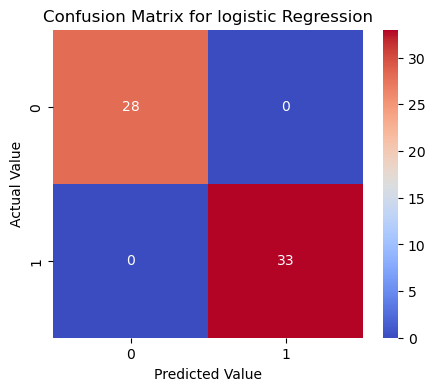

In [24]:
# Plot confusion matrix as heatmap
# Rows = Actual values, Columns = Predicted values             
plt.figure(figsize=(5,4))
sns.heatmap(lr_cm,
            annot=True, # Show counts on cells
            cmap="coolwarm", # Color scheme
            fmt='d')   # Show as integers
plt.title("Confusion Matrix for logistic Regression")
plt.xlabel("Predicted Value") # X axis → Predicted
plt.ylabel("Actual Value") # Y axis → Actual
plt.show()


 Random Forest Accuracy: 
 100.0 %
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        33

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



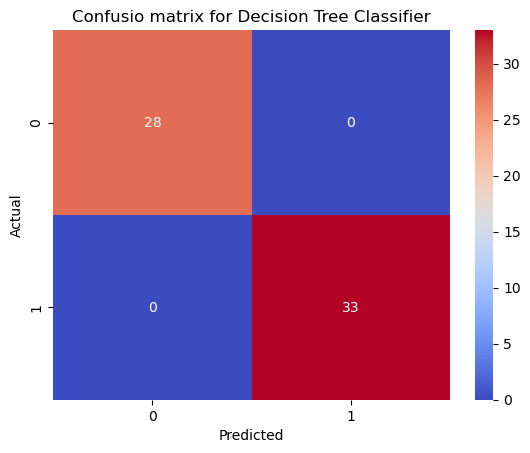

In [25]:
# DECISION TREE CLASSIFIER MODEL
# - DecisionTreeClassifier : Builds tree of decisions
# - fit()                  : Trains model on training data
# - predict()              : Predicts HeartDisease
# - accuracy_score         : Calculates correct prediction %
# - classification_report  : Shows Precision, Recall, F1

from sklearn.tree import DecisionTreeClassifier 
# Create Decision Tree Classifier model object
dt_model = DecisionTreeClassifier()
# Train model using training data
# Builds decision tree based on feature splits
dt_model.fit(x_train,y_train)
# Predict HeartDisease for test data
# Returns array of 0 and 1 predictions
dt_pred = dt_model.predict(x_test)
# Calculate accuracy of Decision Tree model
accuracy_rc = accuracy_score(y_test,dt_pred)
# Calculate confusion matrix for Decision Tree
dt_cm = confusion_matrix(y_test,dt_pred)
# Print accuracy as percentage
print("\n Random Forest Accuracy: \n", round(accuracy_rc * 100,2), "%")
# Print detailed classification report
# Shows Precision, Recall, F1-Score per class
print("Classification Report: \n", classification_report(y_test,dt_pred))


# Plot confusion matrix as heatmap
# Rows = Actual values, Columns = Predicted values
plt.Figure(figsize=(5,4))
sns.heatmap(dt_cm,annot=True,cmap='coolwarm',fmt='d')
plt.title("Confusio matrix for Decision Tree Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [26]:
# COMPARE BOTH MODELS
# - final_result : DataFrame showing accuracy of both models
# - barplot      : Visual comparison of model accuracies
# - Purpose      : Identify which model performs better
# Create DataFrame to compare model accuracies
final_result = pd.DataFrame({
    "Model" : ["LogisticRegression","Decision Tree Classifier"],
    "Accuracy" : [accuracy_lg,accuracy_rc]
})
print("Model Comparision \n", final_result)

Model Comparision 
                       Model  Accuracy
0        LogisticRegression       1.0
1  Decision Tree Classifier       1.0


C:\Users\ahmad\AppData\Local\Temp\ipykernel_30556\3684734301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model",y="Accuracy",data=final_result,palette='coolwarm')


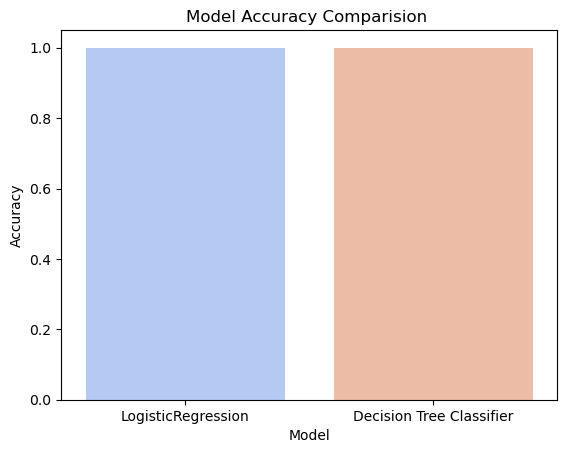

In [27]:
# Plot bar chart to compare model accuracies visually
# Taller bar = Better performing model
plt.Figure(figsize=(6,4))
sns.barplot(x="Model", # X axis → Model names
            y="Accuracy", # Y axis → Accuracy values
            data=final_result, # Data source
            palette='coolwarm') # Color scheme
plt.title("Model Accuracy Comparision ")
plt.show()